## ===============================================
## 🧠 Airline Delay Cause Classification with Keras
## Author: [Your Name]
## Date: [Month, Year]
## Description:
## This notebook builds and evaluates a neural network
## to classify whether weather delays are significant
## (over 100 minutes) using airline delay data.
## ===============================================


In [1]:
# --- Importing Essential Libraries ---
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
# --- Load Dataset ---
data = pd.read_csv('/content/Airline_Delay_Cause.csv')
data.head()


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [3]:
# --- Basic Dataset Info ---
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 318017 non-null  int64  
 1   month                318017 non-null  int64  
 2   carrier              318013 non-null  object 
 3   carrier_name         318013 non-null  object 
 4   airport              318014 non-null  object 
 5   airport_name         318017 non-null  object 
 6   arr_flights          317524 non-null  float64
 7   arr_del15            317285 non-null  float64
 8   carrier_ct           317525 non-null  float64
 9   weather_ct           317523 non-null  float64
 10  nas_ct               317529 non-null  float64
 11  security_ct          317529 non-null  float64
 12  late_aircraft_ct     317529 non-null  float64
 13  arr_cancelled        317529 non-null  float64
 14  arr_diverted         317527 non-null  float64
 15  arr_delay        

In [4]:
# --- Drop Unnecessary Columns ---
# Removing columns that are non-numeric or identifiers
data = data.drop(['carrier', 'carrier_name', 'airport', 'airport_name'], axis=1)

In [5]:
# --- Drop Missing Values ---
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317268 entries, 0 to 318016
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 317268 non-null  int64  
 1   month                317268 non-null  int64  
 2   arr_flights          317268 non-null  float64
 3   arr_del15            317268 non-null  float64
 4   carrier_ct           317268 non-null  float64
 5   weather_ct           317268 non-null  float64
 6   nas_ct               317268 non-null  float64
 7   security_ct          317268 non-null  float64
 8   late_aircraft_ct     317268 non-null  float64
 9   arr_cancelled        317268 non-null  float64
 10  arr_diverted         317268 non-null  float64
 11  arr_delay            317268 non-null  float64
 12  carrier_delay        317268 non-null  float64
 13  weather_delay        317268 non-null  float64
 14  nas_delay            317268 non-null  float64
 15  security_delay       3

In [6]:
# --- Explore Range of Weather Delay ---
print(data['weather_delay'].min(), data['weather_delay'].max())

0.0 57707.0


In [7]:
# --- Create Binary Target Variable ---
# 1 → weather delay > 100 minutes (significant delay)
# 0 → otherwise
data['WDCase'] = data['weather_delay'].apply(lambda x: 1 if x > 100 else 0)

In [8]:
# --- Check Class Distribution ---
data['WDCase'].value_counts()


,count
WDCase,
0,215116
1,102152


In [9]:
# --- Separate Features and Target ---
X = data.drop(['WDCase'], axis=1)
y = data['WDCase']


In [10]:
# --- Split Data into Train/Test Sets ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle =True)

print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (237951, 17)
X_test shape is  (79317, 17)
y_train shape is  (237951,)
y_test shape is  (79317,)


In [11]:
# --- Build Keras Sequential Model ---
import tensorflow as tf
import keras

In [12]:
KerasModel = keras.models.Sequential([
    keras.layers.Dense(8, activation='tanh'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(64, activation='tanh'),
    keras.layers.Dense(32, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

In [13]:
# --- Define Optimizer (Adam with weight decay) ---
Opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    weight_decay=0.004,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    name="Adam"
)


In [14]:
# --- Compile Model ---
KerasModel.compile(optimizer =Opt,loss='binary_crossentropy',metrics=['accuracy'])

In [15]:
# --- Train the Model with Early Stopping ---
history = KerasModel.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=10000,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        patience=10,
        monitor='val_accuracy',
        restore_best_weights=True
    )]
)



Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6780 - loss: 0.6418 - val_accuracy: 0.6773 - val_loss: 0.6054
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6875 - loss: 0.5967 - val_accuracy: 0.7206 - val_loss: 0.5640
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7394 - loss: 0.5560 - val_accuracy: 0.7721 - val_loss: 0.5346
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7714 - loss: 0.5300 - val_accuracy: 0.7727 - val_loss: 0.5168
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7731 - loss: 0.5144 - val_accuracy: 0.7739 - val_loss: 0.5065
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7738 - loss: 0.5041 - val_accuracy: 0.7676 - val_loss: 0.4975
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7744 - loss: 0.4925 - val_accuracy: 0.7785 - val_loss: 0.4857
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7835 - loss: 0.4811 - val_accuracy: 0.

In [16]:
# --- Display Model Summary ---
print(KerasModel.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,997 (136.71 KB)

 Trainable params: 11,665 (45.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,332 (91.14 KB)

None


In [17]:
# --- Save and Reload Model ---
KerasModel.save('KerasModel.h5')
NewKerasModel = keras.models.load_model('KerasModel.h5')

In [18]:
# --- Model Predictions ---
y_pred = NewKerasModel.predict(X_test)
print(f'Prediction Shape: {y_pred.shape}')

2479/2479 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Prediction Shape: (79317, 1)


In [19]:

# --- Evaluate Model on Test Data ---
ModelLoss, ModelAccuracy = NewKerasModel.evaluate(X_test, y_test)
print(f'Model Loss: {(ModelLoss)*100:.2f}')
print(f'Model Accuracy: {(ModelAccuracy)*100:.2f}')


2479/2479 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9976 - loss: 0.0130
Model Loss: 1.32
Model Accuracy: 99.76


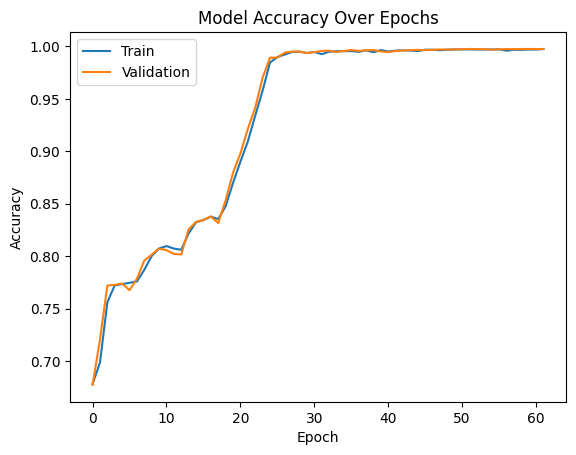

In [20]:
# --- Plot Accuracy over Epochs ---
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


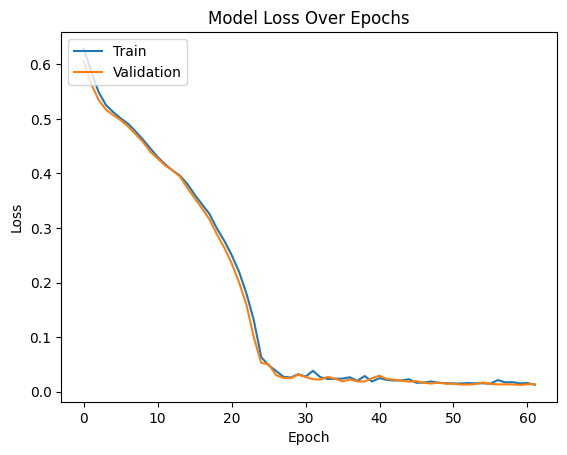

In [21]:
# --- Plot Loss over Epochs ---
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [22]:
# --- Convert Predicted Probabilities to Binary Labels ---
y_pred = [np.round(i[0]) for i in y_pred]

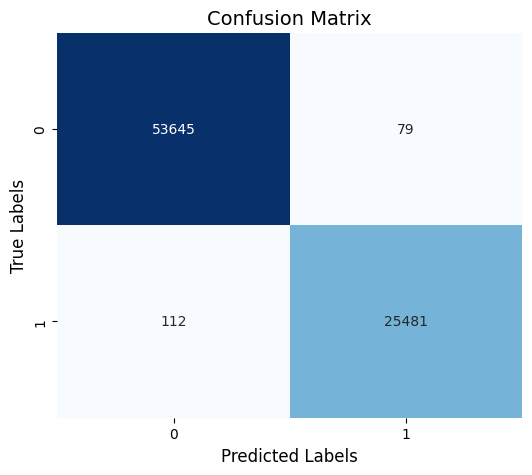

In [23]:
# --- Confusion Matrix Visualization ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

CM = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.show()



In [24]:
# --- Classification Report ---
from sklearn.metrics import classification_report
ClassificationReport = classification_report(y_test, y_pred)
print('Classification Report:\n', ClassificationReport)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     53724
           1       1.00      1.00      1.00     25593

    accuracy                           1.00     79317
   macro avg       1.00      1.00      1.00     79317
weighted avg       1.00      1.00      1.00     79317

